<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/Task8_Classification_Models_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features: sepal length, sepal width, petal length, petal width
y = iris.target  # Target: 0=Setosa, 1=Versicolor, 2=Virginica

# Display basic information about the dataset
print("Dataset shape:", X.shape)
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Number of samples per class:", np.bincount(y))

# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y
print("\nFirst 5 rows of the dataset:")
print(df.head())

Dataset shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Number of samples per class: [50 50 50]

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [3]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Standardize the features (important for Logistic Regression and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature statistics after scaling:")
print("Mean of scaled training features:", X_train_scaled.mean(axis=0).round(3))
print("Standard deviation of scaled training features:", X_train_scaled.std(axis=0).round(3))

Training set size: 120 samples
Testing set size: 30 samples

Feature statistics after scaling:
Mean of scaled training features: [-0. -0.  0.  0.]
Standard deviation of scaled training features: [1. 1. 1. 1.]


LOGISTIC REGRESSION RESULTS
Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


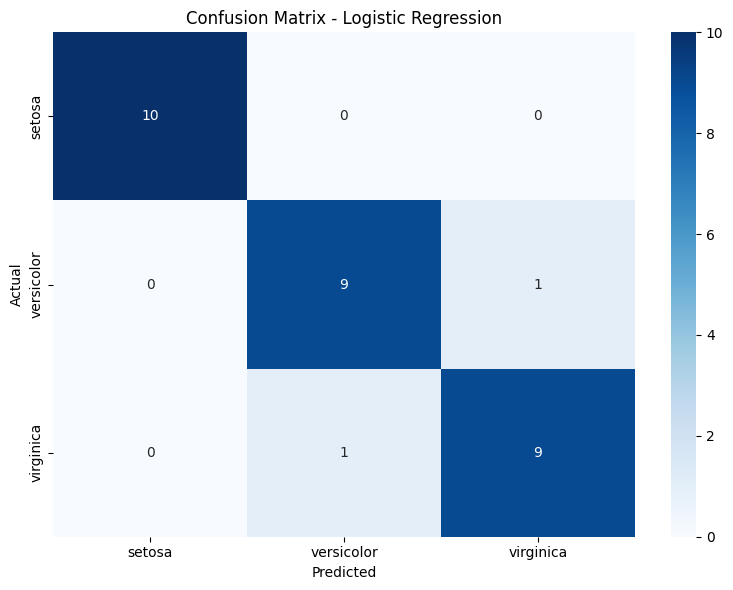

In [5]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Create and train the Logistic Regression model
log_reg = LogisticRegression(max_iter=200, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log = log_reg.predict(X_test_scaled)

# Evaluate the model
accuracy_log = accuracy_score(y_test, y_pred_log)
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_log:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, target_names=iris.target_names))

# Create confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)
print("\nConfusion Matrix:")
print(cm_log)

# Visualize confusion matrix using matplotlib and seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

K-NEAREST NEIGHBORS RESULTS
Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

K VALUE ANALYSIS
k=1: Accuracy = 96.67%
k=2: Accuracy = 93.33%
k=3: Accuracy = 93.33%
k=4: Accuracy = 93.33%
k=5: Accuracy = 93.33%
k=6: Accuracy = 93.33%
k=7: Accuracy = 96.67%
k=8: Accuracy = 93.33%
k=9: Accuracy = 96.67%
k=10: Accuracy = 96.67%
k=11: Accuracy = 96.67%
k=12: Accuracy = 96.67%
k=13: Accuracy = 96.67%
k=14: Accuracy = 96.67%
k=15: Accuracy = 96.67%
k=16: Accuracy = 96.67%
k=17: Accuracy = 96.67%
k=18: Accuracy = 96.67%
k=19: Accuracy = 96.67%
k=20: Accuracy = 96.67%

🏆 Be

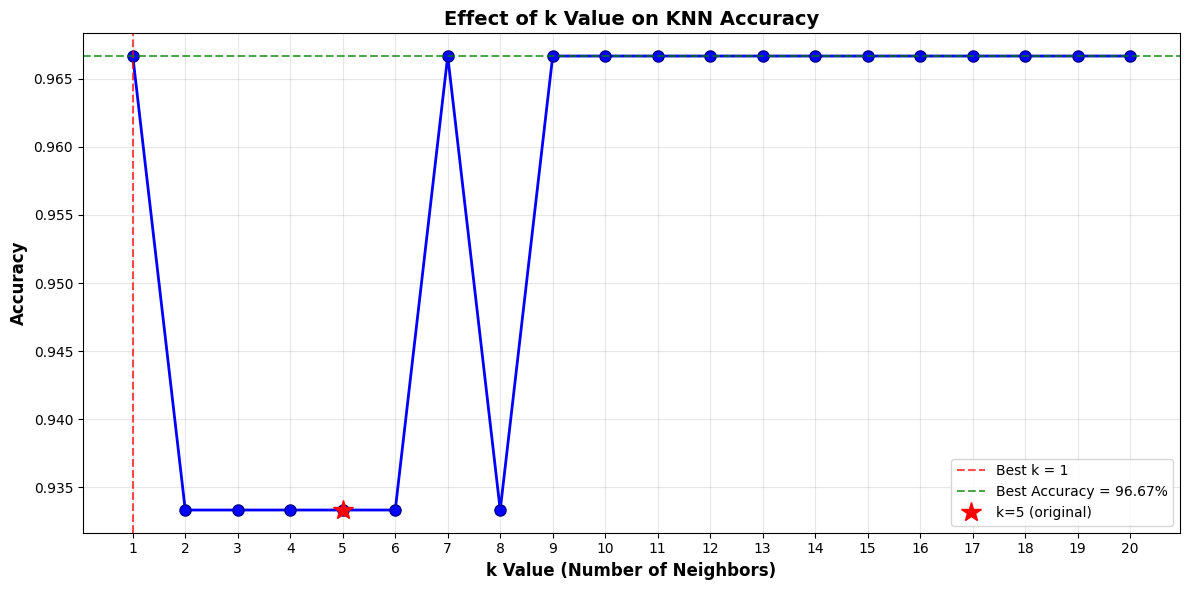

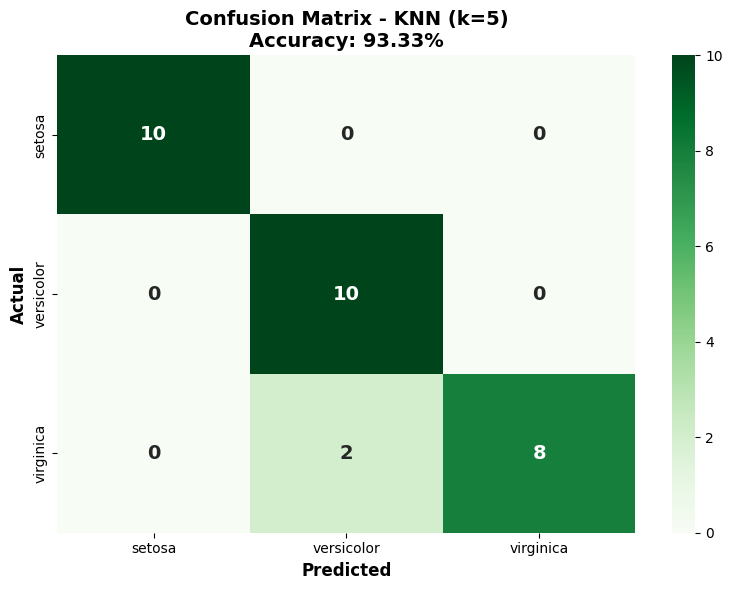

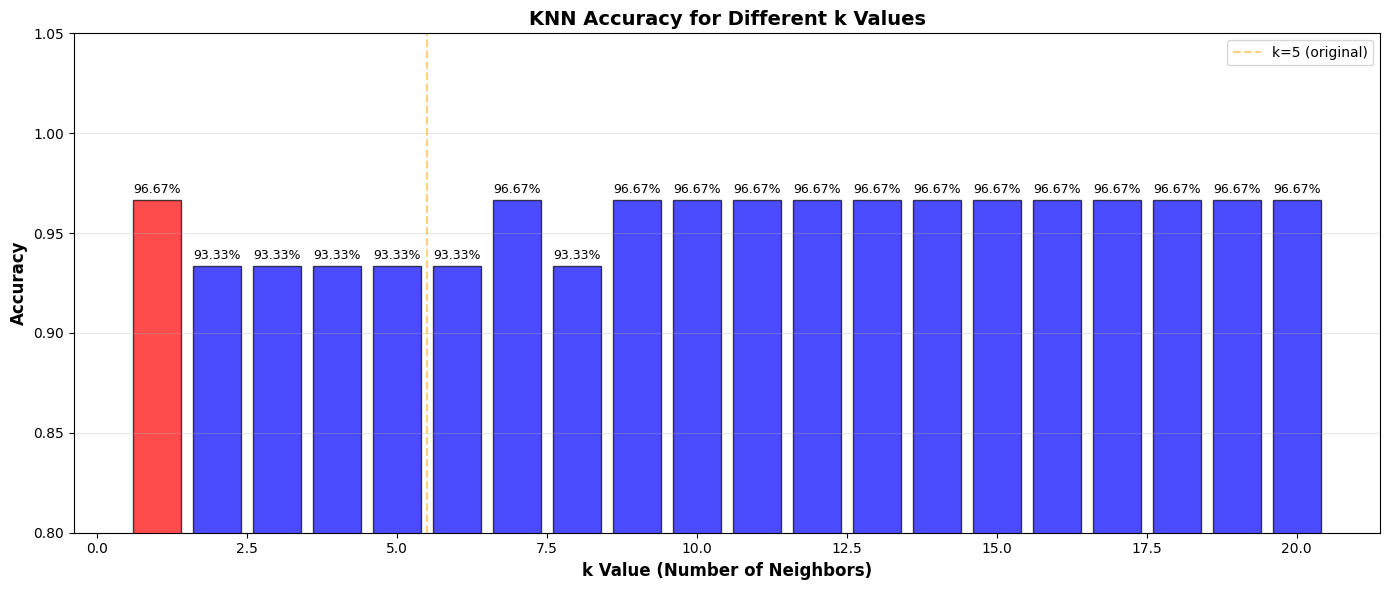


DECISION BOUNDARIES FOR DIFFERENT k VALUES


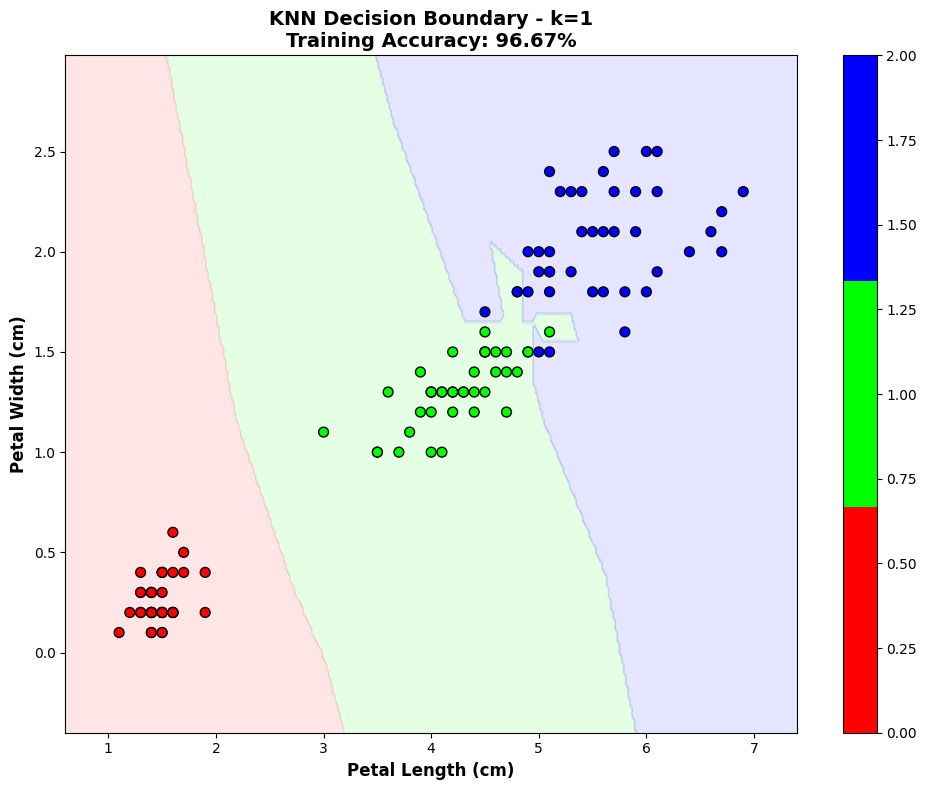

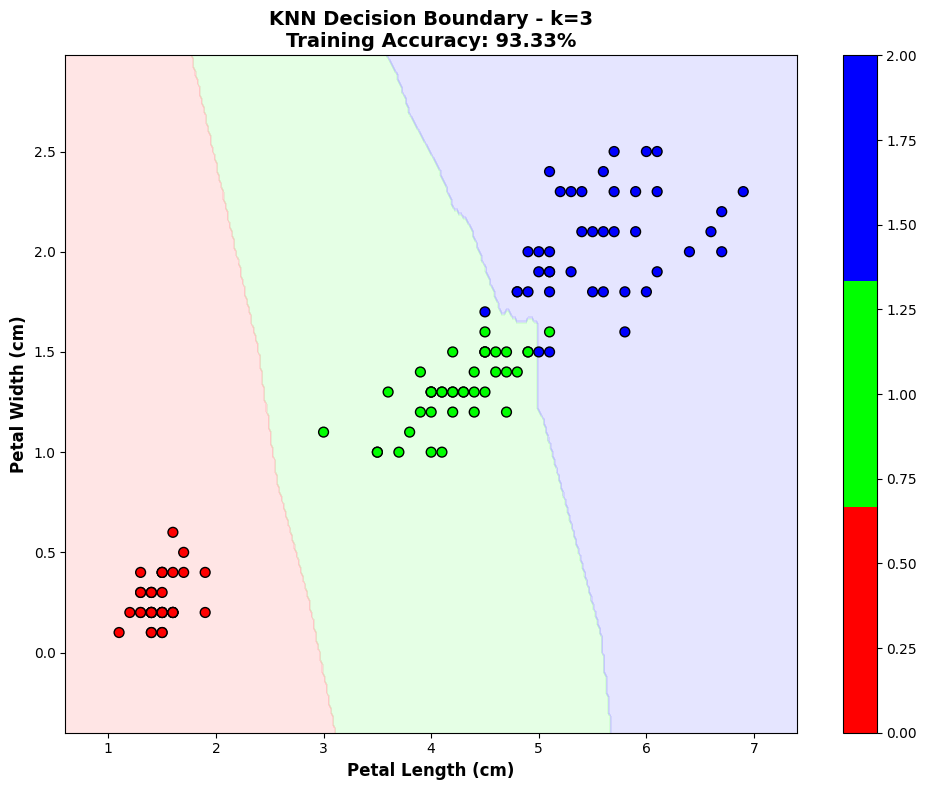

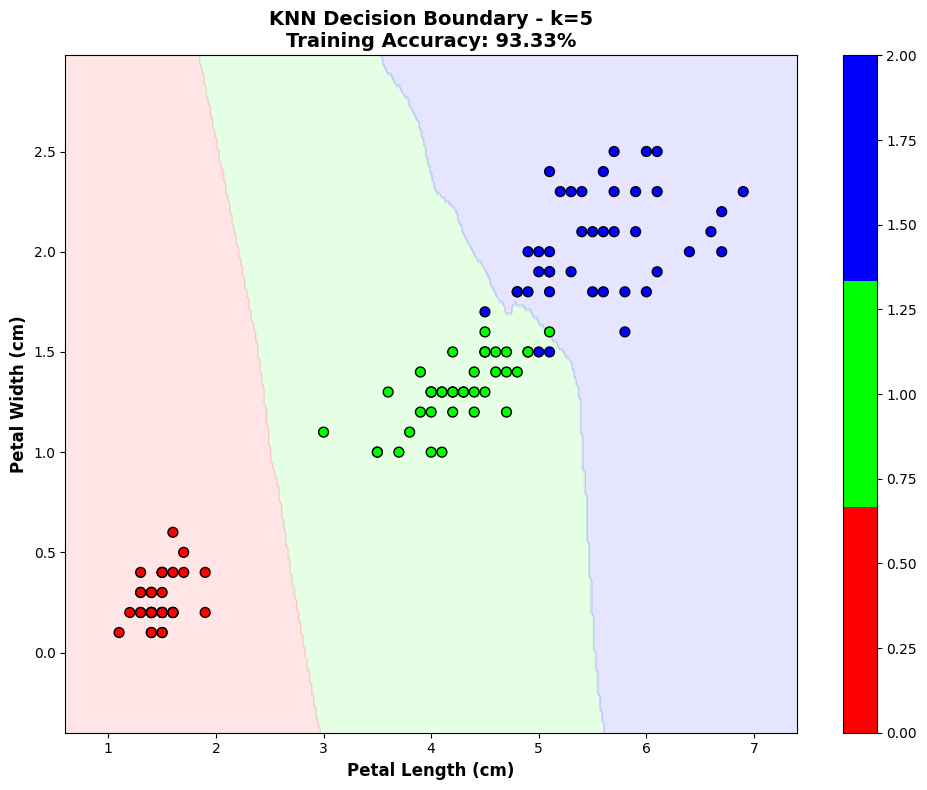

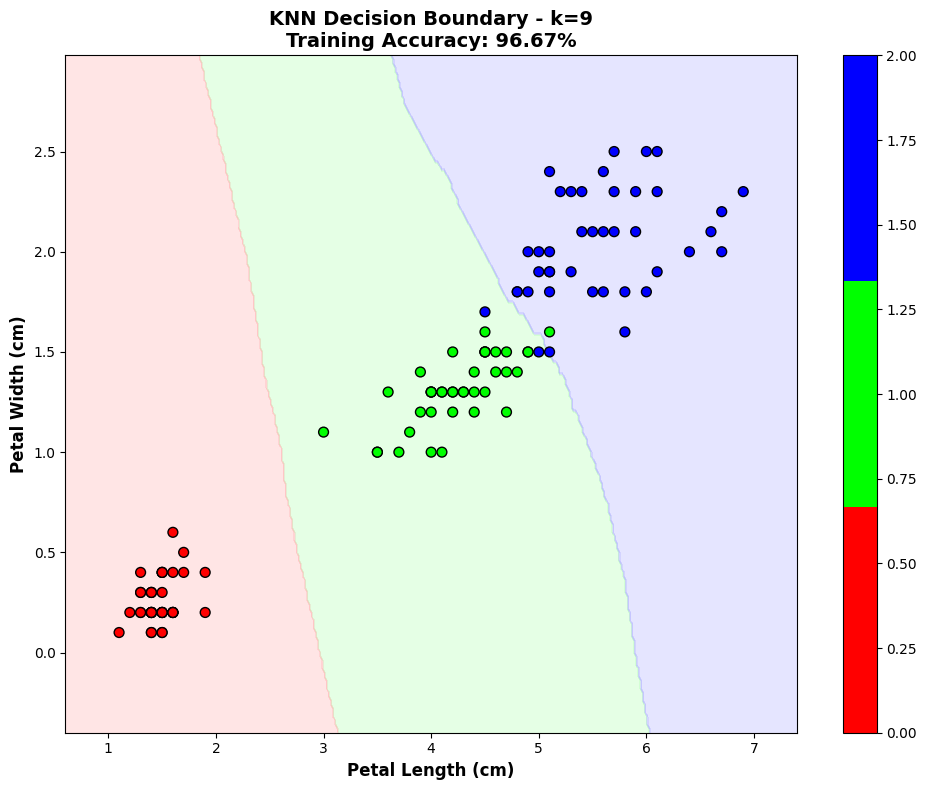

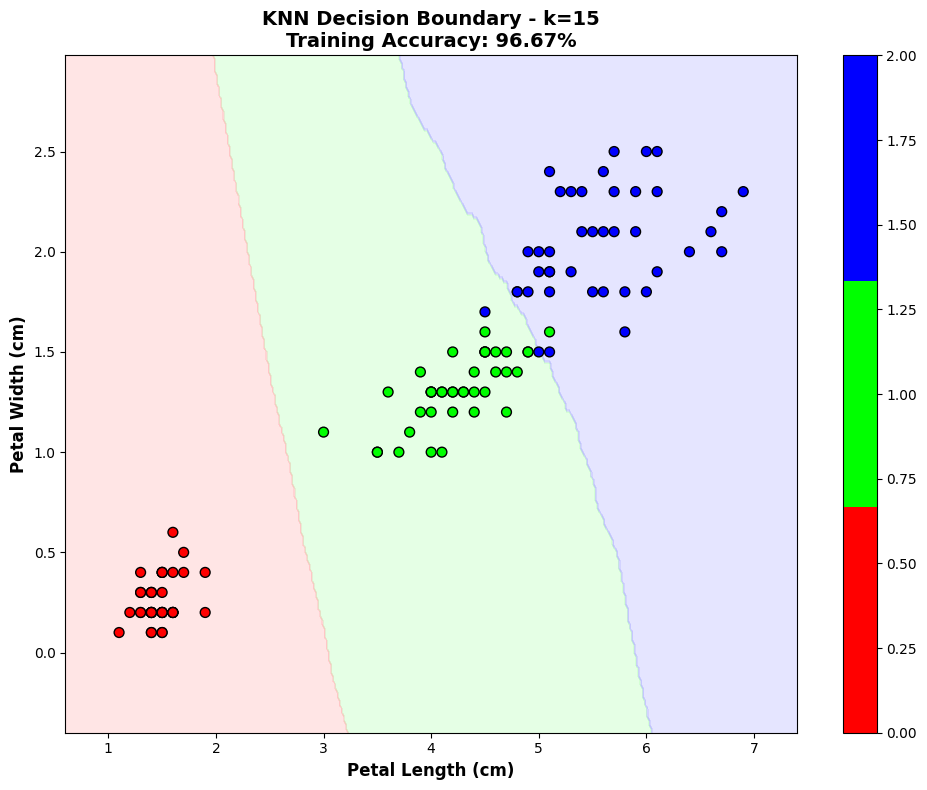

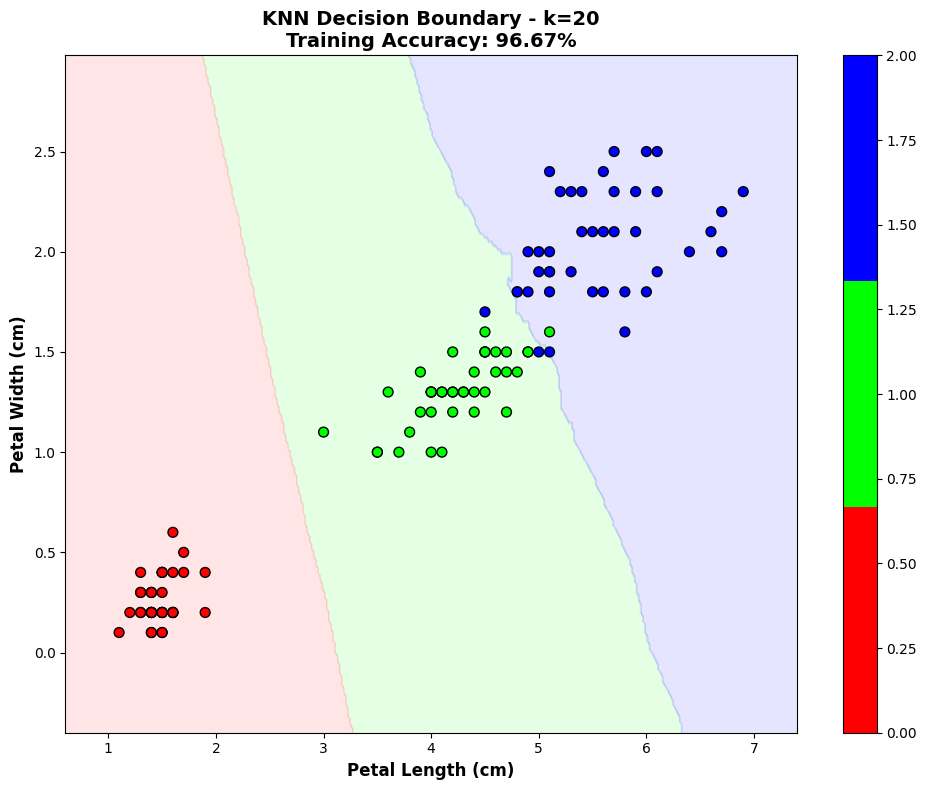

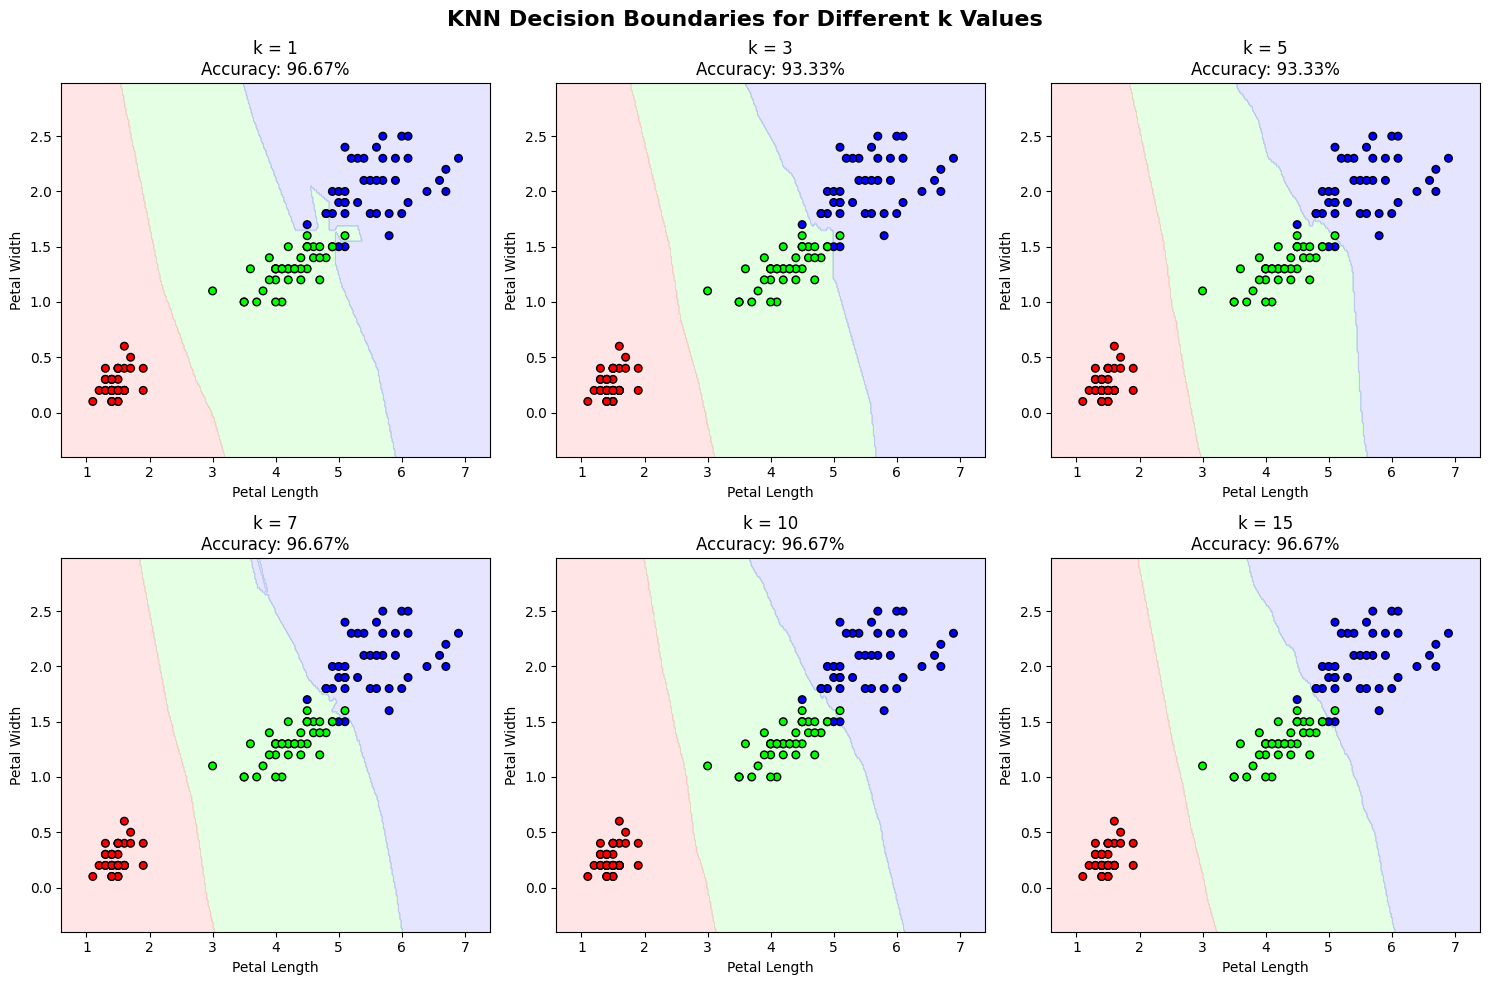


K VALUE SUMMARY TABLE
k Value    Accuracy     Training Set Size
----------------------------------------
1          96.67%            n_neighbors=1
3          93.33%            n_neighbors=3
5          93.33%            n_neighbors=5
7          96.67%            n_neighbors=7
9          96.67%            n_neighbors=9
11         96.67%            n_neighbors=11
15         96.67%            n_neighbors=15
20         96.67%            n_neighbors=20
----------------------------------------
 Best k: 1 with accuracy 96.67%
 Recommended k: 5 (balanced performance)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create and train the KNN model (with k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn.predict(X_test_scaled)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("=" * 50)
print("K-NEAREST NEIGHBORS RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_knn:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

# ============================================
# PART 1: k Value vs Accuracy Plot
# ============================================
print("\n" + "=" * 50)
print("K VALUE ANALYSIS")
print("=" * 50)

k_values = []
accuracies = []
k_range = range(1, 21)  # Test k from 1 to 20

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    acc = knn_temp.score(X_test_scaled, y_test)
    k_values.append(k)
    accuracies.append(acc)
    print(f"k={k}: Accuracy = {acc:.2%}")

# Find the best k
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)
print(f"\n🏆 Best k value: k={best_k} with accuracy {best_accuracy:.2%}")

# Plot k vs Accuracy
plt.figure(figsize=(12, 6))
plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=8, markerfacecolor='blue', markeredgecolor='darkblue')
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k = {best_k}')
plt.axhline(y=best_accuracy, color='green', linestyle='--', alpha=0.7, label=f'Best Accuracy = {best_accuracy:.2%}')

# Highlight the k=5 point (our original choice)
plt.plot(5, accuracies[4], 'r*', markersize=15, label='k=5 (original)')

plt.xlabel('k Value (Number of Neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Effect of k Value on KNN Accuracy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(k_range)
plt.tight_layout()
plt.show()

# ============================================
# PART 2: Confusion Matrix with Visual
# ============================================
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title(f'Confusion Matrix - KNN (k=5)\nAccuracy: {accuracy_knn:.2%}',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# PART 3: k Value vs Accuracy Bar Chart
# ============================================
plt.figure(figsize=(14, 6))
colors = ['red' if k == best_k else 'blue' for k in k_values]
bars = plt.bar(k_values, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1)

# Add value labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=9, rotation=0)

# Mark k=5
plt.axvline(x=5.5, color='orange', linestyle='--', alpha=0.5, label='k=5 (original)')

plt.xlabel('k Value (Number of Neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('KNN Accuracy for Different k Values', fontsize=14, fontweight='bold')
plt.ylim(0.8, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# PART 4: Decision Boundaries for Different k Values
# ============================================
from matplotlib.colors import ListedColormap

def plot_decision_boundary_knn(X_data, y_data, k, title, feature1_idx=2, feature2_idx=3):
    """Plot decision boundary for KNN with different k values"""

    # Select two features for visualization (petal length and petal width)
    X_vis = X_data[:, [feature1_idx, feature2_idx]]

    # Create mesh grid
    x_min, x_max = X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5
    y_min, y_max = X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Train KNN on two features
    knn_vis = KNeighborsClassifier(n_neighbors=k)
    knn_vis.fit(X_vis, y_data)

    # Predict on mesh
    Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_data,
                         cmap=cmap_bold, edgecolor='k', s=50)

    plt.xlabel('Petal Length (cm)', fontsize=12, fontweight='bold')
    plt.ylabel('Petal Width (cm)', fontsize=12, fontweight='bold')
    plt.title(f'KNN Decision Boundary - k={k}\n{title}',
              fontsize=14, fontweight='bold')
    plt.colorbar(scatter)
    plt.tight_layout()
    plt.show()

# Plot decision boundaries for different k values
print("\n" + "=" * 50)
print("DECISION BOUNDARIES FOR DIFFERENT k VALUES")
print("=" * 50)

# Select interesting k values to visualize
k_values_to_plot = [1, 3, 5, 9, 15, 20]

for k_val in k_values_to_plot:
    plot_decision_boundary_knn(
        X_train, y_train,
        k=k_val,
        title=f'Training Accuracy: {KNeighborsClassifier(n_neighbors=k_val).fit(X_train_scaled, y_train).score(X_test_scaled, y_test):.2%}'
    )

# ============================================
# PART 5: All k Values Comparison in One Grid
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
k_grid = [1, 3, 5, 7, 10, 15]

for idx, (ax, k_val) in enumerate(zip(axes.flat, k_grid)):
    # Select two features
    X_vis = X_train[:, [2, 3]]
    knn_vis = KNeighborsClassifier(n_neighbors=k_val)
    knn_vis.fit(X_vis, y_train)

    # Create mesh
    x_min, x_max = X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5
    y_min, y_max = X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    ax.scatter(X_vis[:, 0], X_vis[:, 1], c=y_train,
              cmap=cmap_bold, edgecolor='k', s=30)

    acc = KNeighborsClassifier(n_neighbors=k_val).fit(X_train_scaled, y_train).score(X_test_scaled, y_test)
    ax.set_title(f'k = {k_val}\nAccuracy: {acc:.2%}', fontsize=12)
    ax.set_xlabel('Petal Length')
    ax.set_ylabel('Petal Width')

plt.suptitle('KNN Decision Boundaries for Different k Values', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# PART 6: Summary Table
# ============================================
print("\n" + "=" * 50)
print("K VALUE SUMMARY TABLE")
print("=" * 50)
print(f"{'k Value':<10} {'Accuracy':<12} {'Training Set Size':<15}")
print("-" * 40)
for k in [1, 3, 5, 7, 9, 11, 15, 20]:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    acc = knn_temp.score(X_test_scaled, y_test)
    print(f"{k:<10} {acc:.2%} {' ' * 10} n_neighbors={k}")
print("-" * 40)
print(f" Best k: {best_k} with accuracy {best_accuracy:.2%}")
print(f" Recommended k: 5 (balanced performance)")

DECISION TREE RESULTS
Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Effect of different max_depth values:
max_depth=1: Accuracy = 66.67%
max_depth=2: Accuracy = 93.33%
max_depth=3: Accuracy = 96.67%
max_depth=5: Accuracy = 93.33%
max_depth=10: Accuracy = 93.33%
max_depth=None: Accuracy = 93.33%


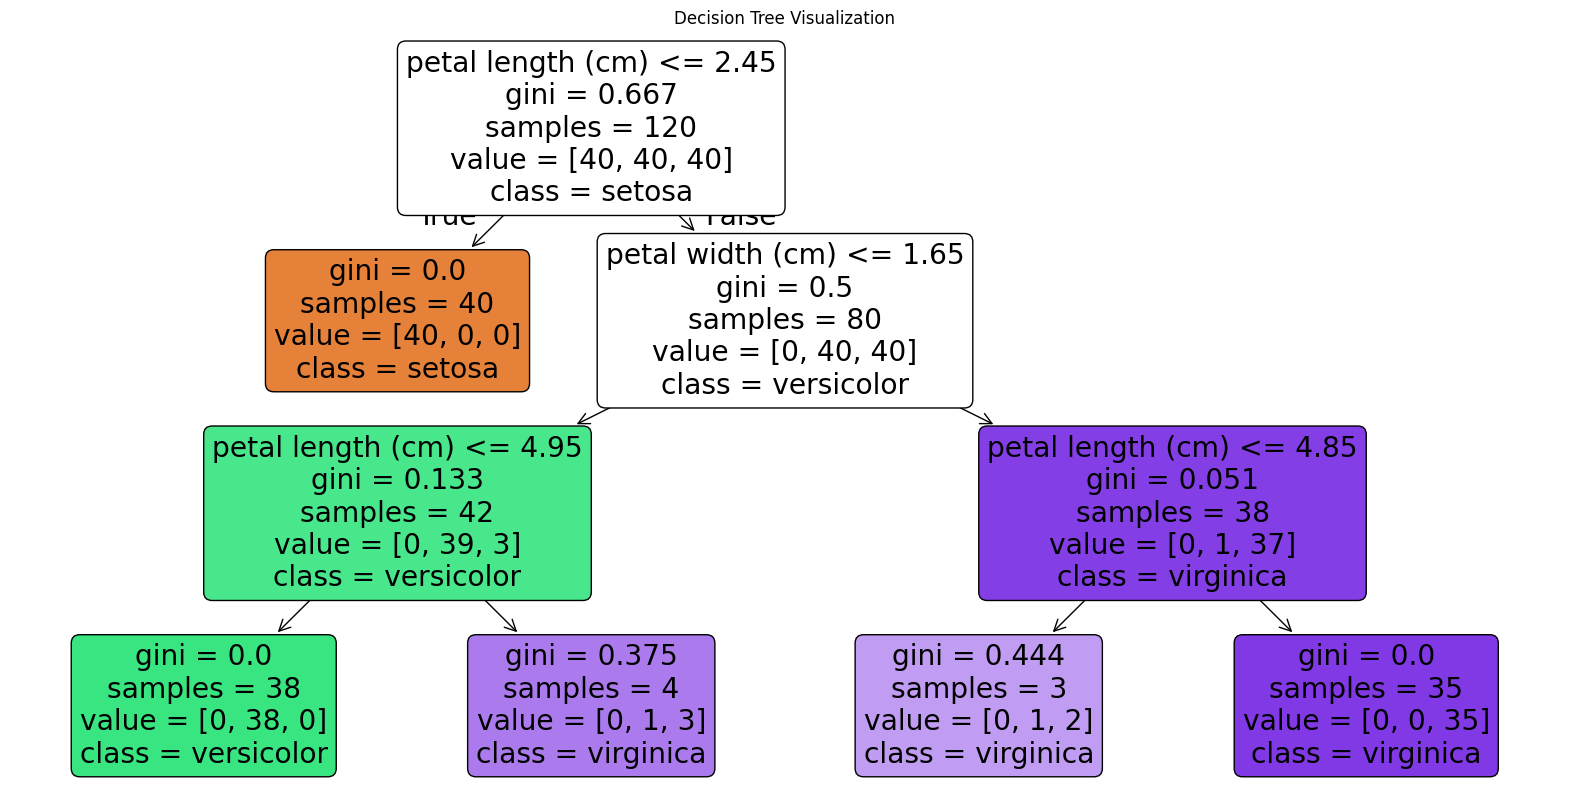

In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Create and train the Decision Tree model
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)  # Note: Decision Trees don't require scaling

# Make predictions
y_pred_tree = tree.predict(X_test)

# Evaluate the model
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print("=" * 50)
print("DECISION TREE RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_tree:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree, target_names=iris.target_names))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

# Try different depths to see the effect
print("\nEffect of different max_depth values:")
for depth in [1, 2, 3, 5, 10, None]:
    tree_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_temp.fit(X_train, y_train)
    acc = tree_temp.score(X_test, y_test)
    print(f"max_depth={depth}: Accuracy = {acc:.2%}")

# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(tree, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

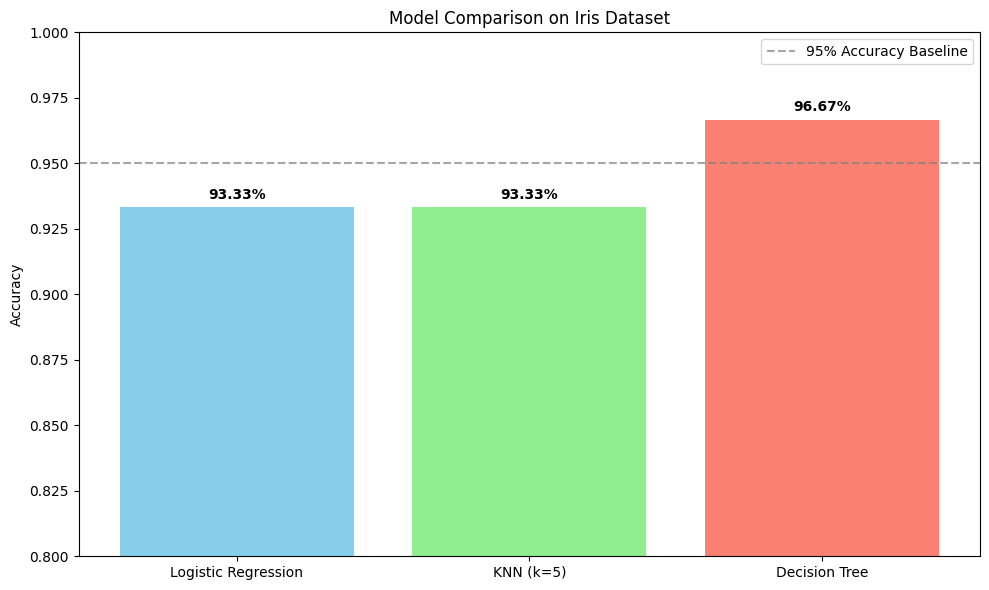

MODEL COMPARISON SUMMARY
Logistic Regression: 93.33%
KNN (k=5):           93.33%
Decision Tree:       96.67%

Best performing model: Decision Tree with 96.67% accuracy


In [8]:
import matplotlib.pyplot as plt

# Store all accuracies
models = ['Logistic Regression', 'KNN (k=5)', 'Decision Tree']
accuracies = [accuracy_log, accuracy_knn, accuracy_tree]

# Create comparison bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Comparison on Iris Dataset')
plt.axhline(y=0.95, color='gray', linestyle='--', alpha=0.7, label='95% Accuracy Baseline')

# Add accuracy values on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.2%}', ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

# Print summary comparison
print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"Logistic Regression: {accuracy_log:.2%}")
print(f"KNN (k=5):           {accuracy_knn:.2%}")
print(f"Decision Tree:       {accuracy_tree:.2%}")

# Find the best model
best_model = models[np.argmax(accuracies)]
best_accuracy = max(accuracies)
print(f"\nBest performing model: {best_model} with {best_accuracy:.2%} accuracy")

In [9]:
# Create a sample flower for prediction
# [sepal_length, sepal_width, petal_length, petal_width]
sample_flower = np.array([[5.0, 3.5, 1.4, 0.2]])  # This looks like a Setosa

print("=" * 50)
print("MAKING PREDICTIONS ON NEW DATA")
print("=" * 50)
print("Sample flower measurements:")
print(f"Sepal Length: {sample_flower[0][0]} cm")
print(f"Sepal Width:  {sample_flower[0][1]} cm")
print(f"Petal Length: {sample_flower[0][2]} cm")
print(f"Petal Width:  {sample_flower[0][3]} cm")

# Predict with all three models
# Scale the sample for Logistic Regression and KNN
sample_scaled = scaler.transform(sample_flower)

# Logistic Regression prediction
pred_log = log_reg.predict(sample_scaled)
pred_log_proba = log_reg.predict_proba(sample_scaled)

# KNN prediction
pred_knn = knn.predict(sample_scaled)
pred_knn_proba = knn.predict_proba(sample_scaled)

# Decision Tree prediction (no scaling needed)
pred_tree = tree.predict(sample_flower)
pred_tree_proba = tree.predict_proba(sample_flower)

# Display predictions
print("\nPredictions:")
print(f"Logistic Regression: {iris.target_names[pred_log[0]]}")
print(f"  Probabilities: Setosa={pred_log_proba[0][0]:.2%}, "
      f"Versicolor={pred_log_proba[0][1]:.2%}, Virginica={pred_log_proba[0][2]:.2%}")

print(f"\nKNN: {iris.target_names[pred_knn[0]]}")
print(f"  Probabilities: Setosa={pred_knn_proba[0][0]:.2%}, "
      f"Versicolor={pred_knn_proba[0][1]:.2%}, Virginica={pred_knn_proba[0][2]:.2%}")

print(f"\nDecision Tree: {iris.target_names[pred_tree[0]]}")
print(f"  Probabilities: Setosa={pred_tree_proba[0][0]:.2%}, "
      f"Versicolor={pred_tree_proba[0][1]:.2%}, Virginica={pred_tree_proba[0][2]:.2%}")

MAKING PREDICTIONS ON NEW DATA
Sample flower measurements:
Sepal Length: 5.0 cm
Sepal Width:  3.5 cm
Petal Length: 1.4 cm
Petal Width:  0.2 cm

Predictions:
Logistic Regression: setosa
  Probabilities: Setosa=98.41%, Versicolor=1.59%, Virginica=0.00%

KNN: setosa
  Probabilities: Setosa=100.00%, Versicolor=0.00%, Virginica=0.00%

Decision Tree: setosa
  Probabilities: Setosa=100.00%, Versicolor=0.00%, Virginica=0.00%
